In [1]:
# Logical operator finder for css codes
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm

# Define stabilizers, use 1 for X and -1 for Z, this will make commutation calculations easy
xxxxiii = np.array([ 1, 1, 1, 1, 0, 0, 0])
xxiixxi = np.array([ 1, 1, 0, 0, 1, 1, 0])
xixixix = np.array([ 1, 0, 1, 0, 1, 0, 1])
zzzziii = np.array([-1,-1,-1,-1, 0, 0, 0])
zziizzi = np.array([-1,-1, 0, 0,-1,-1, 0])
ziziziz = np.array([-1, 0,-1, 0,-1, 0,-1])

stabilizers = [xxxxiii, xxiixxi, xixixix, zzzziii, zziizzi, ziziziz]

def commutes(a, b):
    product = 1
    for i in np.multiply(a, b):
        product *= i if i != 0 else 1
    return product == 1

def commutes_all(a):
    for b in stabilizers:
        if not commutes(a, b):
            return False
    return True

def is_stabilizer(a):
    for b in stabilizers:
        for i in range(len(a)):
            if not np.isclose(a[i], b[i]):
                break
        else:
            return True
    return False

def weight(a):
    return np.sum(np.abs(a))


In [33]:
# X candidates
x_candidates = []
for i in range(1, 2**7):
    candidate = np.zeros(7)
    for j in range(7):
        candidate[j] = 1 if i & (1 << j) else 0
    if commutes_all(candidate) and not is_stabilizer(candidate):
        x_candidates.append(candidate)

# Z candidates
z_candidates = []
for i in range(1, 2**7):
    candidate = np.zeros(7)
    for j in range(7):
        candidate[j] = -1 if i & (1 << j) else 0
    if commutes_all(candidate) and not is_stabilizer(candidate):
        z_candidates.append(candidate)

# Candidate pairs
candidate_pairs = []
for x in x_candidates:
    for z in z_candidates:
        if not commutes(x, z):
            candidate_pairs.append((x, z))

print(len(candidate_pairs))

64


In [34]:
candidate_pairs[-1]

(array([1., 1., 1., 1., 1., 1., 1.]),
 array([-1., -1., -1., -1., -1., -1., -1.]))

In [11]:
# [[15, 7, 3]]

xxxxxxxxiiiiiii = np.array([ 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0])
xxxxiiiixxxxiii = np.array([ 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0])
xxiixxiixxiixxi = np.array([ 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0])
xixixixixixixix = np.array([ 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1])
zzzzzzzziiiiiii = np.array([-1,-1,-1,-1,-1,-1,-1,-1, 0, 0, 0, 0, 0, 0, 0])
zzzziiiizzzziii = np.array([-1,-1,-1,-1, 0, 0, 0, 0,-1,-1,-1,-1, 0, 0, 0])
zziizziizziizzi = np.array([-1,-1, 0, 0,-1,-1, 0, 0,-1,-1, 0, 0,-1,-1, 0])
ziziziziziziziz = np.array([-1, 0,-1, 0,-1, 0,-1, 0,-1, 0,-1, 0,-1, 0,-1])

# Added logical operators as stabilizers
logical_operator1 = np.array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
logical_operator2 = -logical_operator1
logical_operator3 = np.array([0., 0., 1., 0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 1., 1.])
logical_operator4 = -logical_operator3
logical_operator5 = np.array([0., 0., 0., 0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0.])
logical_operator6 = -logical_operator5
stabilizers = [xxxxxxxxiiiiiii, xxxxiiiixxxxiii, xxiixxiixxiixxi, xixixixixixixix, 
            zzzzzzzziiiiiii, zzzziiiizzzziii, zziizziizziizzi, ziziziziziziziz,
            #logical_operator1, logical_operator2, 
            #logical_operator3, logical_operator4,
            #logical_operator5, logical_operator6
            ]

xxxxiiiiiiiiiii = np.array([ 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
for i in stabilizers:
    print(i)

[1 1 1 1 1 1 1 1 0 0 0 0 0 0 0]
[1 1 1 1 0 0 0 0 1 1 1 1 0 0 0]
[1 1 0 0 1 1 0 0 1 1 0 0 1 1 0]
[1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
[-1 -1 -1 -1 -1 -1 -1 -1  0  0  0  0  0  0  0]
[-1 -1 -1 -1  0  0  0  0 -1 -1 -1 -1  0  0  0]
[-1 -1  0  0 -1 -1  0  0 -1 -1  0  0 -1 -1  0]
[-1  0 -1  0 -1  0 -1  0 -1  0 -1  0 -1  0 -1]


In [21]:
# X candidates
x_candidates = []
for i in range(1, 2**15):
    candidate = np.zeros(15)
    for j in range(15):
        candidate[j] = 1 if i & (1 << j) else 0
    if commutes_all(candidate) and not is_stabilizer(candidate) and weight(candidate) == 4:
        x_candidates.append(candidate)

# Z candidates
z_candidates = []
for i in range(1, 2**15):
    candidate = np.zeros(15)
    for j in range(15):
        candidate[j] = -1 if i & (1 << j) else 0
    if commutes_all(candidate) and not is_stabilizer(candidate) and weight(candidate) == 3:
        z_candidates.append(candidate)

# Candidate pairs
candidate_pairs = []
for x in x_candidates:
    for z in z_candidates:
        if not commutes(x, z):
            candidate_pairs.append((x, z))

print(len(x_candidates), len(z_candidates), len(candidate_pairs))

105 35 1680


In [23]:
valid_pairs = []
for pair in candidate_pairs:
    if np.allclose(pair[0], xxxxiiiiiiiiiii, atol=1e-8):
        valid_pairs.append(pair)

print(len(valid_pairs))


16


In [24]:
valid_pairs

[(array([1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
  array([ 0.,  0.,  0., -1., -1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  0.,
          0.,  0.])),
 (array([1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
  array([ 0.,  0., -1.,  0.,  0., -1.,  0.,  0., -1.,  0.,  0.,  0.,  0.,
          0.,  0.])),
 (array([1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
  array([ 0., -1.,  0.,  0.,  0.,  0., -1.,  0., -1.,  0.,  0.,  0.,  0.,
          0.,  0.])),
 (array([1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
  array([-1.,  0.,  0.,  0.,  0.,  0.,  0., -1., -1.,  0.,  0.,  0.,  0.,
          0.,  0.])),
 (array([1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
  array([ 0.,  0., -1.,  0., -1.,  0.,  0.,  0.,  0., -1.,  0.,  0.,  0.,
          0.,  0.])),
 (array([1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
  array([ 0.,  0.,  0., -1.,  0., -1.,  0.,  0.,  0., -1.,  0.,  0.,  0.,
          0.,  0.]))

In [49]:
weight7candidates = []
for candidate in candidate_pairs:
    if weight(candidate[0]) == 7 and weight(candidate[1]) == 7:
        weight7candidates.append(candidate)

print(len(weight7candidates))

108585


(array([1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), array([ 0., -1., -1., -1., -1., -1., -1.,  0., -1., -1., -1.,  0., -1.,
        0.,  0.]))


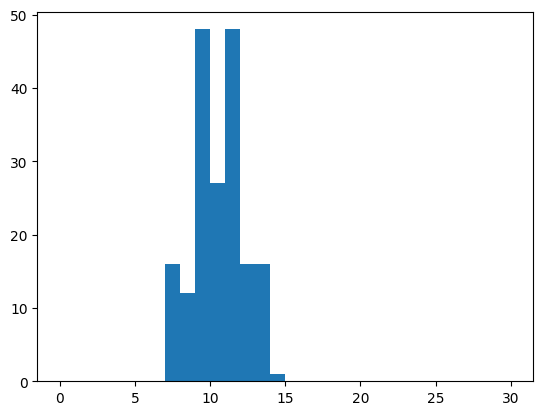

In [44]:
lengths = []
for i in range(len(candidate_pairs)):
    lengths.append(np.sum(np.abs(candidate_pairs[i][0]) + np.abs(candidate_pairs[i][1])))
    if np.sum(np.abs(candidate_pairs[i][0]) + np.abs(candidate_pairs[i][1])) == 14:
        print(candidate_pairs[i])
        break
plt.hist(lengths, bins=np.arange(0, 31, 1))
plt.show()




In [7]:
# With new "gauge" construction

# Original stabilizers
xxxxxxxxiiiiiii = np.array([ 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0])
xxxxiiiixxxxiii = np.array([ 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0])
xxiixxiixxiixxi = np.array([ 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0])
xixixixixixixix = np.array([ 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1])
zzzzzzzziiiiiii = np.array([-1,-1,-1,-1,-1,-1,-1,-1, 0, 0, 0, 0, 0, 0, 0])
zzzziiiizzzziii = np.array([-1,-1,-1,-1, 0, 0, 0, 0,-1,-1,-1,-1, 0, 0, 0])
zziizziizziizzi = np.array([-1,-1, 0, 0,-1,-1, 0, 0,-1,-1, 0, 0,-1,-1, 0])
ziziziziziziziz = np.array([-1, 0,-1, 0,-1, 0,-1, 0,-1, 0,-1, 0,-1, 0,-1])
# gauges
xxxxiiiiiiiiiii = np.array([ 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
xiiixiiixiiixii = np.array([ 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0])
zzzziiiiiiiiiii = np.array([-1,-1,-1,-1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
ziiiziiiziiizii = np.array([-1, 0, 0, 0,-1, 0, 0, 0,-1, 0, 0, 0,-1, 0, 0])

# Added logical operators as stabilizers
stabilizers = [xxxxxxxxiiiiiii, xxxxiiiixxxxiii, xxiixxiixxiixxi, xixixixixixixix, 
            zzzzzzzziiiiiii, zzzziiiizzzziii, zziizziizziizzi, ziziziziziziziz,
            xxxxiiiiiiiiiii, xiiixiiixiiixii, zzzziiiiiiiiiii, ziiiziiiziiizii
            ]

for i in stabilizers:
    print(i)

[1 1 1 1 1 1 1 1 0 0 0 0 0 0 0]
[1 1 1 1 0 0 0 0 1 1 1 1 0 0 0]
[1 1 0 0 1 1 0 0 1 1 0 0 1 1 0]
[1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
[-1 -1 -1 -1 -1 -1 -1 -1  0  0  0  0  0  0  0]
[-1 -1 -1 -1  0  0  0  0 -1 -1 -1 -1  0  0  0]
[-1 -1  0  0 -1 -1  0  0 -1 -1  0  0 -1 -1  0]
[-1  0 -1  0 -1  0 -1  0 -1  0 -1  0 -1  0 -1]
[1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
[1 0 0 0 1 0 0 0 1 0 0 0 1 0 0]
[-1 -1 -1 -1  0  0  0  0  0  0  0  0  0  0  0]
[-1  0  0  0 -1  0  0  0 -1  0  0  0 -1  0  0]


In [29]:
# X candidates
x_candidates = []
for i in tqdm(range(1, 2**15)):
    candidate = np.zeros(15)
    for j in range(15):
        candidate[j] = 1 if i & (1 << j) else 0
    if commutes_all(candidate) and not is_stabilizer(candidate): #and weight(candidate) == 7:
        x_candidates.append(candidate)

# Z candidates
z_candidates = []
for i in tqdm(range(1, 2**15)):
    candidate = np.zeros(15)
    for j in range(15):
        candidate[j] = -1 if i & (1 << j) else 0
    if commutes_all(candidate) and not is_stabilizer(candidate): #and weight(candidate) == 7:
        z_candidates.append(candidate)

# Candidate pairs
candidate_pairs = []
for x in tqdm(x_candidates):
    for z in z_candidates:
        if not commutes(x, z):
            candidate_pairs.append((x, z))

print(len(x_candidates), len(z_candidates), len(candidate_pairs))

100%|██████████| 2043/2043 [00:06<00:00, 302.37it/s]

2043 2043 2080768


In [28]:
for x in x_candidates:
    if np.array_equal(x, xiiixiiixiiixii):
        print(x)


[1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0.]


In [33]:
relevant_pairs = []
for pair in tqdm(candidate_pairs):
    if np.array_equal(pair[0], xiiixiiixiiixii) and weight(pair[1]) == 3:
        relevant_pairs.append(pair)
relevant_pairs = np.array(relevant_pairs)
print(len(relevant_pairs))




100%|██████████| 2080768/2080768 [00:02<00:00, 759803.50it/s]

16


In [34]:
relevant_pairs[0:10,1]

array([[ 0.,  0., -1.,  0.,  0., -1.,  0.,  0., -1.,  0.,  0.,  0.,  0.,
         0.,  0.],
       [ 0., -1.,  0.,  0.,  0.,  0., -1.,  0., -1.,  0.,  0.,  0.,  0.,
         0.,  0.],
       [ 0.,  0., -1.,  0., -1.,  0.,  0.,  0.,  0., -1.,  0.,  0.,  0.,
         0.,  0.],
       [-1.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0., -1.,  0.,  0.,  0.,
         0.,  0.],
       [ 0., -1.,  0.,  0., -1.,  0.,  0.,  0.,  0.,  0., -1.,  0.,  0.,
         0.,  0.],
       [-1.,  0.,  0.,  0.,  0., -1.,  0.,  0.,  0.,  0., -1.,  0.,  0.,
         0.,  0.],
       [ 0., -1., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,
         0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -1., -1.,  0.,  0.,  0.,  0.,  0., -1.,
         0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1., -1.,  0., -1.,
         0.,  0.],
       [-1.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        -1.,  0.]])